In [3]:
pip install seaborn-darkgrid

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement seaborn-darkgrid (from versions: none)
ERROR: No matching distribution found for seaborn-darkgrid


importing packeges for further data manupulation

# project report on stock prediction using Support Vectoe Machine(SVM) #

# Executive Summary #
# Purpose : #
in todays market stock prediction is one of the leading way to check your prediction accuracy specificly using SVM 

# Table of Contents #
 # 1. data import
#  2. Methodology
#  3. Results
#  4. Conculation


In [1]:
# Machine learning 
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score 
import seaborn as sns
# For data manipulation 
import pandas as pd 
import numpy as np 

# To plot 
import matplotlib.pyplot as plt 
plt.style.use('seaborn-v0_8-darkgrid')

# To ignore warnings 
import warnings 
warnings.filterwarnings("ignore")

In [2]:
# Read the csv file using read_csv 

df = pd.read_csv("D:\machine learning\Reliance.csv") 
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-11-18,463.799988,465.649994,454.975006,456.000000,436.671021,5142766.0
1,2015-11-19,459.450012,469.350006,458.625000,467.375000,447.563873,5569752.0
2,2015-11-20,467.000000,476.399994,462.774994,473.424988,453.357422,5167930.0
3,2015-11-23,475.000000,478.950012,473.100006,476.875000,456.661224,4800026.0
4,2015-11-24,476.500000,485.799988,475.524994,483.850006,463.340515,6768886.0
...,...,...,...,...,...,...,...
1228,2020-11-10,2077.000000,2090.000000,2041.199951,2084.550049,2084.550049,17045147.0
1229,2020-11-11,2089.000000,2095.000000,1978.099976,1997.199951,1997.199951,26178477.0
1230,2020-11-12,1981.000000,2008.449951,1965.000000,1980.000000,1980.000000,18481466.0
1231,2020-11-13,1982.000000,2036.650024,1981.750000,1996.400024,1996.400024,20946864.0


In [3]:
# Changes The Date column as index columns 
df.index = pd.to_datetime(df['Date']) 
df 

# drop The original date column 
df = df.drop(['Date'], axis='columns') 
df 

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-11-18,463.799988,465.649994,454.975006,456.000000,436.671021,5142766.0
2015-11-19,459.450012,469.350006,458.625000,467.375000,447.563873,5569752.0
2015-11-20,467.000000,476.399994,462.774994,473.424988,453.357422,5167930.0
2015-11-23,475.000000,478.950012,473.100006,476.875000,456.661224,4800026.0
2015-11-24,476.500000,485.799988,475.524994,483.850006,463.340515,6768886.0
...,...,...,...,...,...,...
2020-11-10,2077.000000,2090.000000,2041.199951,2084.550049,2084.550049,17045147.0
2020-11-11,2089.000000,2095.000000,1978.099976,1997.199951,1997.199951,26178477.0
2020-11-12,1981.000000,2008.449951,1965.000000,1980.000000,1980.000000,18481466.0


Here first we are convert the "Date" column into the index of the dataframe and then remove the original "date" column to reduce the redudantcy

In [4]:
import numpy as np

# Fill missing values with the mean of each column
df.fillna(df.mean(), inplace=True)

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill remaining NaN values with zero
df.fillna(0, inplace=True)

# Define le10
le10 = 0

# Fill remaining NaN values with le10
df.fillna(le10, inplace=True)

# Print the count of NaN values in each column
print("Null values in each column:")
print(df.isnull().sum())

# Print the count of non-null values in each column
print("Non-null values in each column:")
print(df.notnull().sum())


Null values in each column:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
Non-null values in each column:
Open         1233
High         1233
Low          1233
Close        1233
Adj Close    1233
Volume       1233
dtype: int64


Data contains  missing values, NaN values.
To prepair the data for further process, filling missing values with the mean and replacing NaN values with Zero.
This process ensures all the missing values are replacd with specific value.

After the preprocessing steps ensure that the DataFrame is cleaned and prepared for further analysis.

In [5]:
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [6]:
# Create predictor variables 
df['Open-Close'] = df.Open - df.Close 
df['High-Low'] = df.High - df.Low 

# Store all predictor variables in a variable X 
X = df[['Open-Close', 'High-Low']] 
X.head()

,Open-Close,High-Low
Date,,
2015-11-18,7.799988,10.674988
2015-11-19,-7.924988,10.725006
2015-11-20,-6.424988,13.625000
2015-11-23,-1.875000,5.850006
2015-11-24,-7.350006,10.274994


Applying feature engineering by creating new columns in the DataFrame to represent price differences ('Open-Close' and 'High-Low'), which are then stored as predictor variables in the DataFrame "X"

In [7]:
# Target variables 
y = np.where(df['Close'].shift(-1) > df['Close'], 1, 0) 
y


array([1, 1, 1, ..., 1, 0, 0])

"Close" column moved one row up, to compares the next days closing price to todays closing price.
It's results in Boolean array where if the next days closing price is greater than todays closinf price then "TRUE: 1" or "FALSE: 0"



In [8]:
split_percentage = 0.75
split = int(split_percentage*len(df)) 

# Train data set 
X_train = X[:split] 
y_train = y[:split] 

# Test data set 
X_test = X[split:] 
y_test = y[split:]

75% of the data is going to use for Train the model and 25% of the data will be reserved for testing the model.


In [9]:

X.isnull().sum()

Open-Close    0
High-Low      0
dtype: int64

In [10]:
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Define SVC model
svc = SVC()
cls=svc.fit(X_train, y_train)




Setting up traning an SVC model using scikit-learn for classification task, and model is initilize with default hyperparameters and trained on the provided traning data set.

In [11]:
from sklearn.metrics import accuracy_score

# Predictions on training set
train_predictions = cls.predict(X_train)
# Compute train accuracy
train_accuracy = accuracy_score(y_train, train_predictions)
print("Train Accuracy:", train_accuracy)

# Predictions on test set
test_predictions = cls.predict(X_test)
# Compute test accuracy
test_accuracy = accuracy_score(y_test, test_predictions)
print("Test Accuracy:", test_accuracy)


Train Accuracy: 0.551948051948052
Test Accuracy: 0.4627831715210356


Evalute  the effectiveness of the SVC model by comparing it's performence on both training and testing data set.

Performence of the model is moderate level,
further improvement is needed

In [12]:
df['Predicted_Signal'] = cls.predict(X)

Genereting predicted signals using the trained SVC model for the given features and stores then in a new column 

In [13]:
# Calculate daily returns 
df['Return'] = df.Close.pct_change()

This method calculates the percentage change between the current and previous element. For the 'Close' column, it computes the daily return as the percentage change from the previous day’s closing price.
This column helps to understand how the price is mob=ving on day-to-day basis.

In [14]:
# Calculate strategy returns 
df['Strategy_Return'] = df.Return *df.Predicted_Signal.shift(1)

This function shifts the 'Predicted_Signal' column down by one period,means that the trading decision based on the previous day’s signal.

In [15]:
# Calculate Cumulutive returns 
df['Cum_Ret'] = df['Return'].cumsum() 
df

,Open,High,Low,Close,Adj Close,Volume,Open-Close,High-Low,Predicted_Signal,Return,Strategy_Return,Cum_Ret
Date,,,,,,,,,,,,
2015-11-18,463.799988,465.649994,454.975006,456.000000,436.671021,5142766.0,7.799988,10.674988,1,NaN,NaN,NaN
2015-11-19,459.450012,469.350006,458.625000,467.375000,447.563873,5569752.0,-7.924988,10.725006,1,0.024945,0.024945,0.024945
2015-11-20,467.000000,476.399994,462.774994,473.424988,453.357422,5167930.0,-6.424988,13.625000,1,0.012945,0.012945,0.037890
2015-11-23,475.000000,478.950012,473.100006,476.875000,456.661224,4800026.0,-1.875000,5.850006,1,0.007287,0.007287,0.045177
2015-11-24,476.500000,485.799988,475.524994,483.850006,463.340515,6768886.0,-7.350006,10.274994,1,0.014626,0.014626,0.059804
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-11-10,2077.000000,2090.000000,2041.199951,2084.550049,2084.550049,17045147.0,-7.550049,48.800049,1,0.016507,0.000000,1.866347
2020-11-11,2089.000000,2095.000000,1978.099976,1997.199951,1997.199951,26178477.0,91.800049,116.900024,1,-0.041904,-0.041904,1.824444
2020-11-12,1981.000000,2008.449951,1965.000000,1980.000000,1980.000000,18481466.0,1.000000,43.449951,1,-0.008612,-0.008612,1.815832


In [16]:
# Plot Strategy Cumulative returns  
df['Cum_Strategy'] = df['Strategy_Return'].cumsum() 
df

,Open,High,Low,Close,Adj Close,Volume,Open-Close,High-Low,Predicted_Signal,Return,Strategy_Return,Cum_Ret,Cum_Strategy
Date,,,,,,,,,,,,,
2015-11-18,463.799988,465.649994,454.975006,456.000000,436.671021,5142766.0,7.799988,10.674988,1,NaN,NaN,NaN,NaN
2015-11-19,459.450012,469.350006,458.625000,467.375000,447.563873,5569752.0,-7.924988,10.725006,1,0.024945,0.024945,0.024945,0.024945
2015-11-20,467.000000,476.399994,462.774994,473.424988,453.357422,5167930.0,-6.424988,13.625000,1,0.012945,0.012945,0.037890,0.037890
2015-11-23,475.000000,478.950012,473.100006,476.875000,456.661224,4800026.0,-1.875000,5.850006,1,0.007287,0.007287,0.045177,0.045177
2015-11-24,476.500000,485.799988,475.524994,483.850006,463.340515,6768886.0,-7.350006,10.274994,1,0.014626,0.014626,0.059804,0.059804
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-11-10,2077.000000,2090.000000,2041.199951,2084.550049,2084.550049,17045147.0,-7.550049,48.800049,1,0.016507,0.000000,1.866347,1.778568
2020-11-11,2089.000000,2095.000000,1978.099976,1997.199951,1997.199951,26178477.0,91.800049,116.900024,1,-0.041904,-0.041904,1.824444,1.736665
2020-11-12,1981.000000,2008.449951,1965.000000,1980.000000,1980.000000,18481466.0,1.000000,43.449951,1,-0.008612,-0.008612,1.815832,1.728053


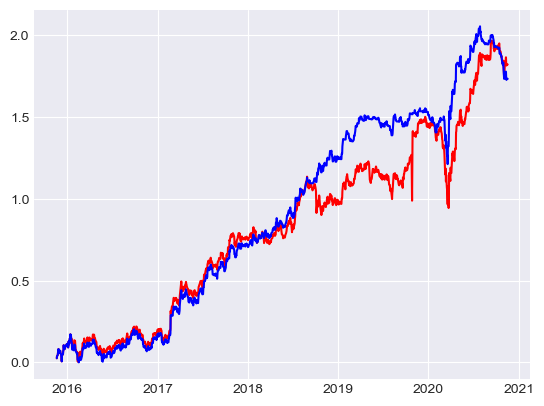

In [17]:
import matplotlib.pyplot as plt 
%matplotlib inline 

plt.plot(df['Cum_Ret'],color='red') 
plt.plot(df['Cum_Strategy'],color='blue')


Visually comparing the performence of the model and its predicton accuracy 

In [18]:
# Predict on the test set
y_pred = cls.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy*100,2))

Accuracy: 46.28


The overall accuracy of 46.28% suggests that the classifier's performance is quite low.

# testing accuracy of the other models #

# time series analysis #

In [27]:
import pandas as pd

# Assuming df is your main DataFrame and it is indexed appropriately with a time index
# Let's assume you want to use the last 30 points for testing

n_test = 30  # Define how many data points to use for testing

# Splitting the data into training and test sets
train_data_cum_ret = df['Cum_Ret'][:-n_test]
test_data_cum_ret = df['Cum_Ret'][-n_test:]

train_data_cum_strategy = df['Cum_Strategy'][:-n_test]
test_data_cum_strategy = df['Cum_Strategy'][-n_test:]

# Ensure these lines are before you use 'test_data_cum_ret' in your code


In [28]:
# Assuming 'df' is your DataFrame and it's indexed by date
# Let's split the last 'n' records as test data
n = 30  # Number of periods you want to forecast, adjust this based on your dataset size

# Create test data for Cum_Ret
test_data_cum_ret = df['Cum_Ret'][-n:]
train_data_cum_ret = df['Cum_Ret'][:-n]

# Create test data for Cum_Strategy
test_data_cum_strategy = df['Cum_Strategy'][-n:]
train_data_cum_strategy = df['Cum_Strategy'][:-n]


In [29]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model for Cum_Ret
model_cum_ret = ARIMA(train_data_cum_ret, order=(1, 1, 1))
fitted_cum_ret = model_cum_ret.fit()

# Fit ARIMA model for Cum_Strategy
model_cum_strategy = ARIMA(train_data_cum_strategy, order=(1, 1, 1))
fitted_cum_strategy = model_cum_strategy.fit()


C:\Users\Rupam\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Rupam\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Rupam\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Rupam\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(d

In [30]:
# Assuming you have fitted your ARIMA models as shown in previous examples:
# Predict using ARIMA model for 'Cum_Ret'
predictions_cum_ret = fitted_cum_ret.get_forecast(steps=len(test_data_cum_ret))
predicted_means_cum_ret = predictions_cum_ret.predicted_mean

# Predict using ARIMA model for 'Cum_Strategy'
predictions_cum_strategy = fitted_cum_strategy.get_forecast(steps=len(test_data_cum_strategy))
predicted_means_cum_strategy = predictions_cum_strategy.predicted_mean


C:\Users\Rupam\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Rupam\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate MSE and MAE for Cum_Ret
mse_cum_ret = mean_squared_error(test_data_cum_ret, predicted_means_cum_ret)
mae_cum_ret = mean_absolute_error(test_data_cum_ret, predicted_means_cum_ret)

# Calculate MSE and MAE for Cum_Strategy
mse_cum_strategy = mean_squared_error(test_data_cum_strategy, predicted_means_cum_strategy)
mae_cum_strategy = mean_absolute_error(test_data_cum_strategy, predicted_means_cum_strategy)

print(f"Cum_Ret - MSE: {mse_cum_ret}, MAE: {mae_cum_ret}")
print(f"Cum_Strategy - MSE: {mse_cum_strategy}, MAE: {mae_cum_strategy}")


Cum_Ret - MSE: 0.006175467908749861, MAE: 0.06356531559045925
Cum_Strategy - MSE: 0.013801466303314119, MAE: 0.09373544007558789


# resul of other model #
The reported MSE and MAE values provide insights into the accuracy of predictions made by a model. Lower values of MSE and MAE indicate better accuracy, as they suggest that the predicted values are closer to the actual values. 
But the graphical representation of the model prediction is clearly falling in the department of the prediction part.


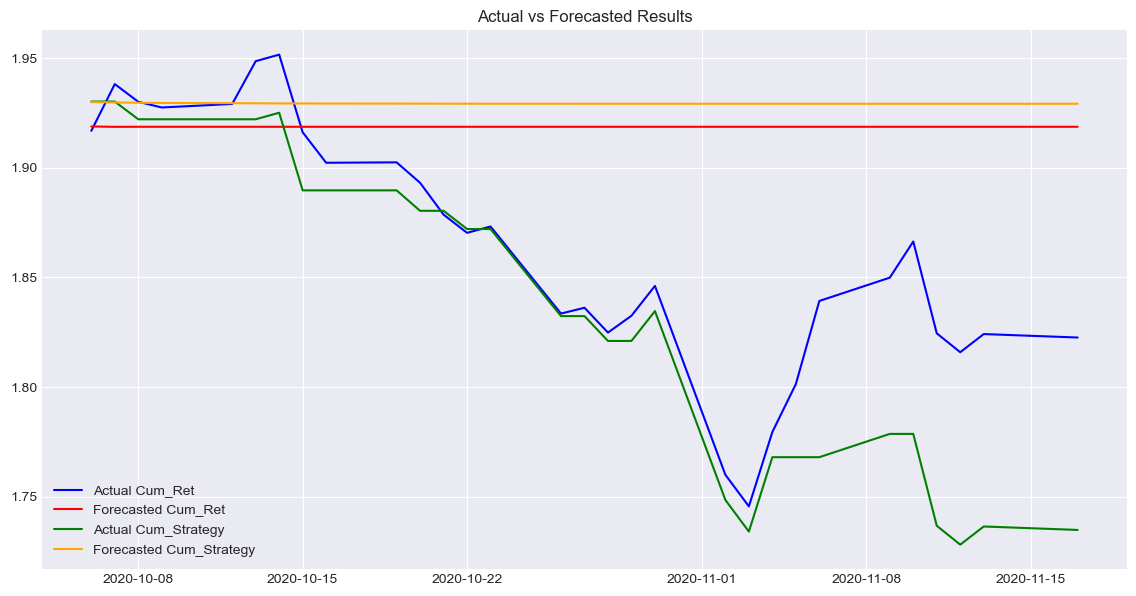

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(test_data_cum_ret.index, test_data_cum_ret, label='Actual Cum_Ret', color='blue')
plt.plot(test_data_cum_ret.index, predicted_means_cum_ret, label='Forecasted Cum_Ret', color='red')
plt.plot(test_data_cum_strategy.index, test_data_cum_strategy, label='Actual Cum_Strategy', color='green')
plt.plot(test_data_cum_strategy.index, predicted_means_cum_strategy, label='Forecasted Cum_Strategy', color='orange')
plt.title('Actual vs Forecasted Results')
plt.legend()
plt.show()


# Conculation #

While the model achieves a moderate level of accuracy on the training data (55.20%), its performance drops significantly when evaluated on unseen test data (46.28%).
This discrepancy between training and testing accuracies suggests potential issues with model generalization, such as overfitting or underfitting.
Further analysis, such as tuning model hyperparameters or using different algorithms, may be necessary to improve the model's performance on unseen data.

compare to other model it gives a better prediction even it's performence is low